# Ejercicio 7: péndulo con amortiguamiento — función de Lyapunov y retrato de fases

*(Traducción a Python de `ejercicio7.m` + `ej7.m`, usando `sympy`, `numpy`, `scipy` y `matplotlib`)*

$$\dot x_1 = x_2, \qquad \dot x_2 = -\sin(x_1) - \epsilon x_2$$

**Nota curiosa sobre el archivo original:** dentro de `ej7.m`, la función está declarada internamente como `function dotx = ej8(t,x,epsilon)` — el nombre interno no coincide con el nombre del archivo (`ej7.m`). Esto **sí funciona en MATLAB** (para el archivo/función principal, MATLAB usa el nombre del archivo para localizarla al llamarla, no el nombre interno tras `function`), pero **no tiene sentido en Python**: aquí una función se llama por el nombre con el que la defines con `def`, así que la llamamos `ej7` directamente, sin ambigüedad.

In [1]:
import sympy as sp
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

sp.init_printing()
np.set_printoptions(precision=4, suppress=True)

## Función de estado (equivalente a `ej7.m`)

In [2]:
def ej7(t, x, epsilon):
    """Ecuaciones de estado del pendulo con amortiguamiento."""
    x1, x2 = x
    return [x2, -np.sin(x1) - epsilon*x2]

## Puntos singulares y linealización

In [3]:
x1, x2, epsilon, s = sp.symbols('x1 x2 epsilon s', real=True)

f = sp.Matrix([
    x2,
    -sp.sin(x1) - epsilon*x2
])
J = f.jacobian([x1, x2])
J

⎡   0      1 ⎤
⎢            ⎥
⎣-cos(x₁)  -ε⎦

In [4]:
soluciones = sp.solve(f, [x1, x2], dict=True)
soluciones

`sympy` encuentra dos equilibrios dentro de su rango de solución habitual, $x_1=0$ y $x_1=\pi$ (en realidad hay infinitos, $x_1=k\pi$ para cualquier entero $k$, por la periodicidad del seno — ni MATLAB ni `sympy` los dan todos automáticamente). El `.m` original solo trabaja con uno ("solo hay uno así que abrevio", dice el comentario), así que seguimos igual y usamos el primero, $(0,0)$.

In [5]:
Je = J.subs(soluciones[0])
E = sp.simplify(Je.eigenvals())
print('Je =')
display(Je)
print('autovalores:')
E

Je =


⎡0   1 ⎤
⎢      ⎥
⎣-1  -ε⎦

autovalores:


Estable para $\epsilon>0$ (parte real negativa de ambos autovalores).

## Función de Lyapunov

Proponemos la función de energía del péndulo,

$$V = 1-\cos(x_1) + \frac{x_2^2}{2}$$

In [6]:
V = 1 - sp.cos(x1) + x2**2/2

grv = sp.Matrix([sp.diff(V, x1), sp.diff(V, x2)])
dotV = sp.simplify((grv.T * f)[0, 0])
dotV

$\dot V = -\epsilon x_2^2$, semidefinida negativa: de nuevo un caso para aplicar LaSalle, igual que en el ejercicio 5.

## Retrato de fases

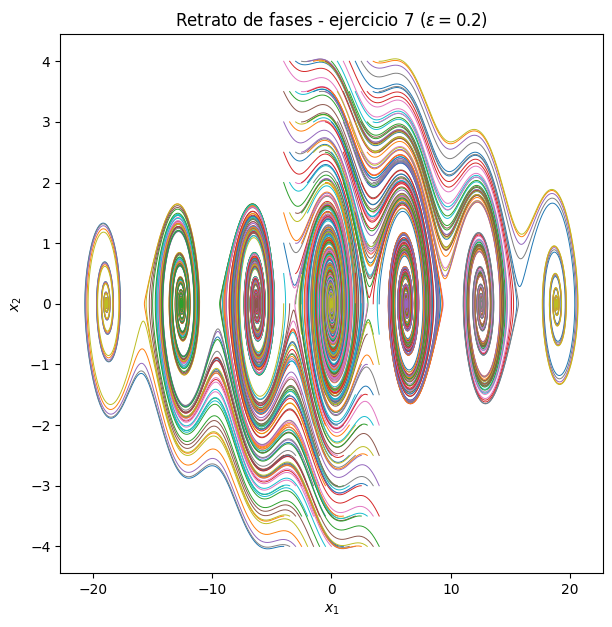

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))

for i in np.arange(-4, 4.001, 0.5):
    for j in np.arange(-4, 4.001, 0.5):
        sol = solve_ivp(ej7, [0, 50], [i, j], args=(0.2,), max_step=0.05)
        ax.plot(sol.y[0], sol.y[1], linewidth=0.7)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title(r'Retrato de fases - ejercicio 7 ($\epsilon=0.2$)')
plt.show()

Dibujamos también el círculo límite que impone la propia función de Lyapunov (fuera de ese límite no se cumple $V>0$ globalmente en $x_2=0$; si usamos LaSalle nos valen todos los puntos de equilibrio del oscilador).

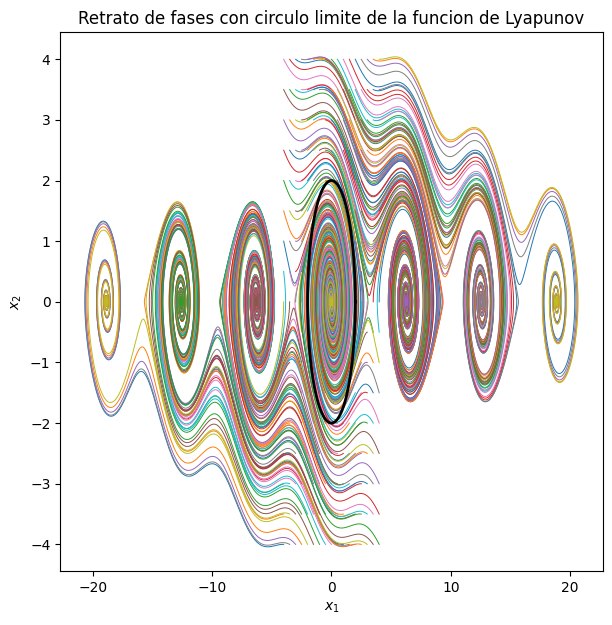

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))

for i in np.arange(-4, 4.001, 0.5):
    for j in np.arange(-4, 4.001, 0.5):
        sol = solve_ivp(ej7, [0, 50], [i, j], args=(0.2,), max_step=0.05)
        ax.plot(sol.y[0], sol.y[1], linewidth=0.7)

theta = np.arange(0, 2*np.pi + 0.01, np.pi/100)
xc = 2*np.cos(theta)
yc = 2*np.sin(theta)
ax.plot(xc, yc, 'k', linewidth=2)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Retrato de fases con circulo limite de la funcion de Lyapunov')
plt.show()